Text(0.5, 1.0, 'Time Spent Chatting with AI Daily')

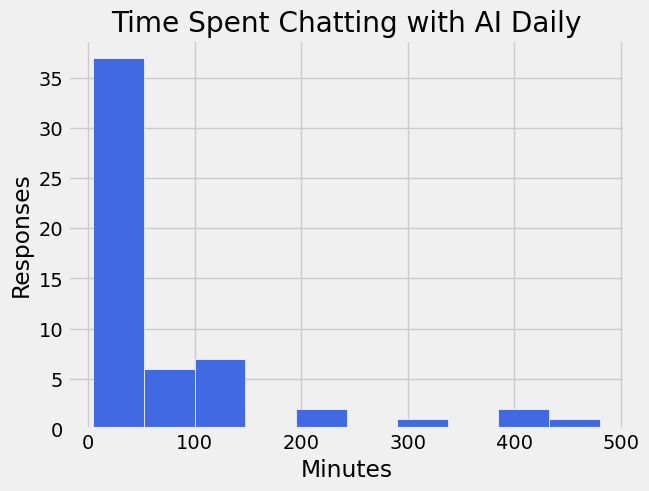

In [1]:
# Don't change this cell; just run it. 

import numpy as np
from datascience import *
import warnings
warnings.simplefilter('ignore', FutureWarning)

import matplotlib
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

# Load your survey data into a Table
survey_results = Table.read_table('FormResponses1.csv')
survey_results = survey_results.relabeled('On average how many minutes per day do you spend chatting with an AI? ', 'Minutes')

minutes_data = survey_results.column('Minutes')
plots.hist(minutes_data, bins=10, color='royalblue', edgecolor='white')

#labels
plots.xlabel('Minutes')
plots.ylabel('Responses')
plots.title('Time Spent Chatting with AI Daily')


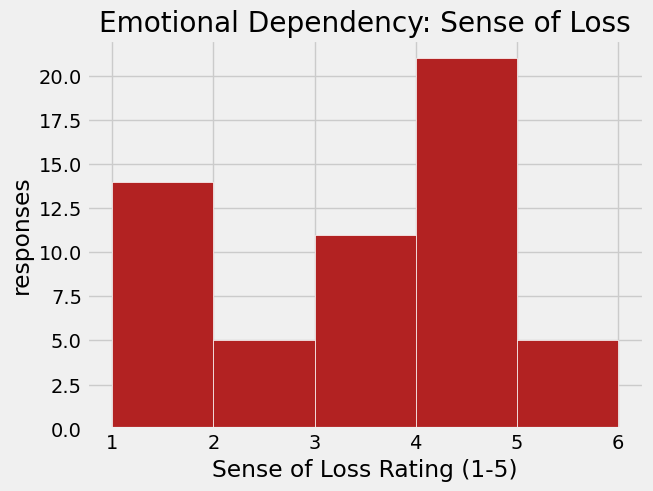

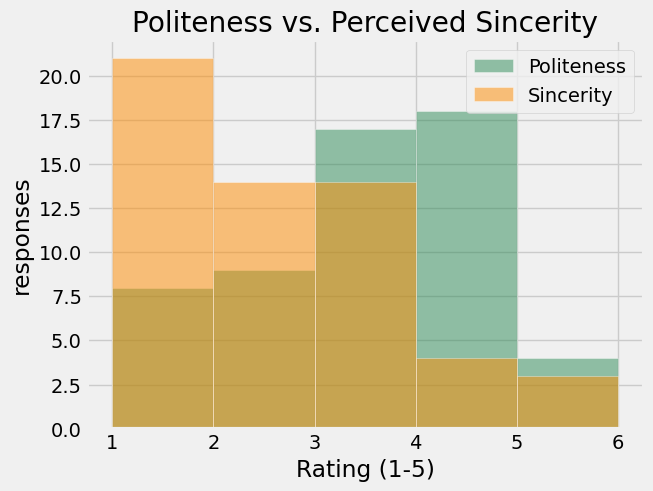

In [2]:
# Histogram 1: Sense of Loss
loss_data = survey_results.column('I would feel a significant sense of loss if I could no longer access my preferred AI.')
plots.hist(loss_data, bins=np.arange(1, 7, 1), color='firebrick', edgecolor='white')
plots.xlabel('Sense of Loss Rating (1-5)')
plots.ylabel('responses')
plots.title('Emotional Dependency: Sense of Loss')
plots.show()

# Histogram 2: The Politeness vs. Sincerity
# 1. Grab the two columns
polite_data = survey_results.column('I feel a moral obligation be polite or kind when messaging the AI.')
sincere_data = survey_results.column('When the AI claims to understand my feelings, I perceive that sentiment as sincere.')

# 2. Plot both in the same cell
# alpha=0.5 makes them transparent so you can see the overlap
plots.hist(polite_data, bins=np.arange(1, 7, 1), alpha=0.5, label='Politeness', color='seagreen', edgecolor='white')
plots.hist(sincere_data, bins=np.arange(1, 7, 1), alpha=0.5, label='Sincerity', color='darkorange', edgecolor='white')

# 3. Add labels and legend
plots.xlabel('Rating (1-5)')
plots.ylabel('responses')
plots.title('Politeness vs. Perceived Sincerity')
plots.legend(loc='upper right')


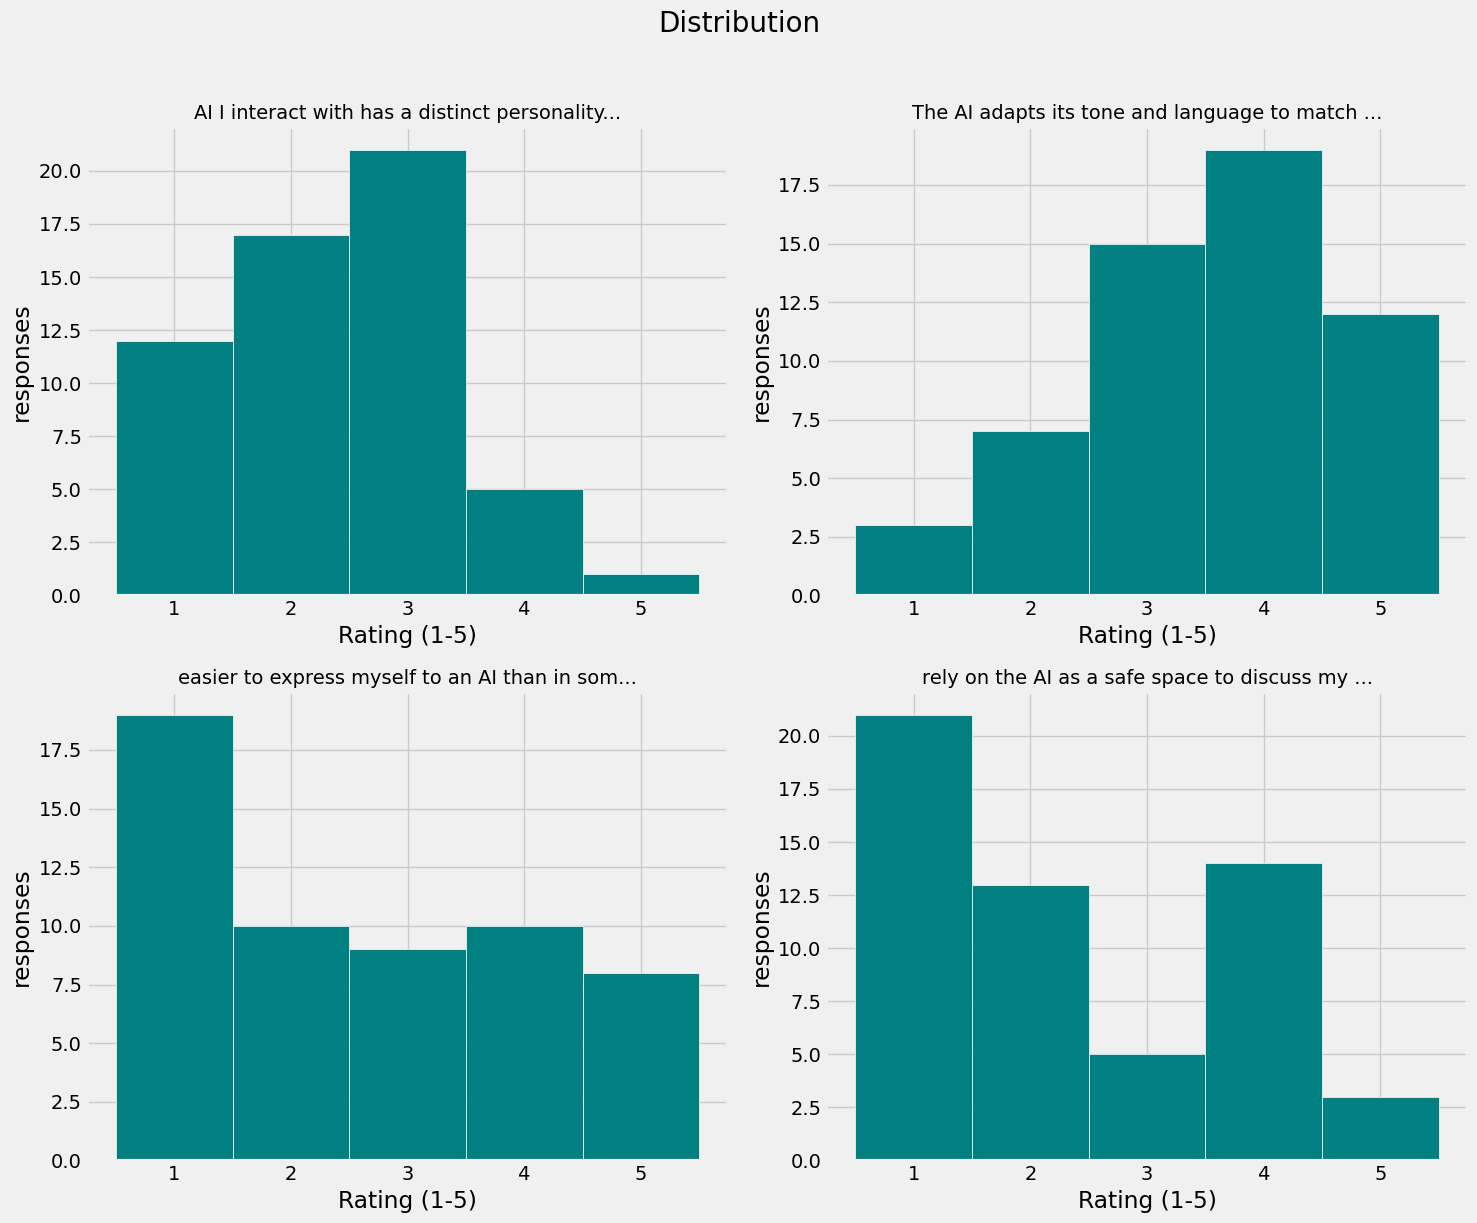

In [3]:
# 1. Define the columns we want to look at
bonding_cols = make_array(
    'I feel like the AI I interact with has a distinct personality.',
    'The AI adapts its tone and language to match my specific communication style.',
    'I find it easier to express myself to an AI than in some face-to-face conversations.',
    'I can rely on the AI as a safe space to discuss my personal problems.'
)

# 2. Create the 2x2 Grid using the 'plots' (Matplotlib) library
# figsize (15, 12) gives enough room for labels without overlapping
fig, axes = plots.subplots(2, 2, figsize=(15, 12))
plots.suptitle('Distribution', fontsize=20, y=1.02)
axes = axes.flatten()

# 3. Loop through and generate the histograms
for i in np.arange(len(bonding_cols)):
    col_name = bonding_cols.item(i)
    data = survey_results.column(col_name)
    
    axes[i].hist(data, bins=np.arange(1, 7, 1), color='teal', edgecolor='white', align='left')
    
    # Cleaning up the titles (Shortening the long questions)
    short_title = col_name.replace('I feel like the ', '').replace('I find it ', '').replace('I can ', '')
    axes[i].set_title(short_title[:45] + "...", fontsize=14)
    
    # Applying your specific formatting
    axes[i].set_xticks([1, 2, 3, 4, 5])
    axes[i].set_ylabel('responses')
    axes[i].set_xlabel('Rating (1-5)')

# Prevent everything from being squished
plots.tight_layout()


In [6]:
import pandas as pd
import numpy as np

# 1. Load finalized data
df = pd.read_csv('FormResponses1.csv')

# 2. Clean the column names (removes invisible spaces at the start/end)
df.columns = df.columns.str.strip()

# 3. Robust TVD Function
def calculate_tvd(df, col1, col2):
    # This creates a frequency table for ratings 1 through 5
    # normalize=True turns counts into proportions (percentages)
    # .reindex(range(1, 6), fill_value=0) ensures even ratings with 0 responses are counted
    stats1 = df[col1].value_counts(normalize=True).reindex(range(1, 6), fill_value=0)
    stats2 = df[col2].value_counts(normalize=True).reindex(range(1, 6), fill_value=0)
    
    # TVD Formula: 0.5 * Sum of Absolute Differences
    return 0.5 * np.sum(np.abs(stats1 - stats2))

# 4. Define the Column Names (copied exactly from survey)
safe_space = 'I can rely on the AI as a safe space to discuss my personal problems.'
loss = 'I would feel a significant sense of loss if I could no longer access my preferred AI.'
express = 'I find it easier to express myself to an AI than in some face-to-face conversations.'
personality = 'I feel like the AI I interact with has a distinct personality.'
tone = 'The AI adapts its tone and language to match my specific communication style.'
polite = 'I feel a moral obligation be polite or kind when messaging the AI.'
sincere = 'When the AI claims to understand my feelings, I perceive that sentiment as sincere.'
comp = 'I view my ongoing interactions with the AI as a form of companionship.'

# 5. Calculate and Print the Results
results = {
    "Consistency Check: Ease of Expression vs. Safe Space": calculate_tvd(df, express, safe_space),
    "Consistency Check: Loss vs. Companionship": calculate_tvd(df, loss, comp),
    "Paradox Check: Politeness vs. Sincerity": calculate_tvd(df, polite, sincere),
    "Paradox Check: Personality vs. Tone Adaptation": calculate_tvd(df, personality, tone),
}

print("--- Total Variation Distance (TVD) Results ---")
for label, score in results.items():
    print(f"{label}: {score:.4f}")

--- Total Variation Distance (TVD) Results ---
Consistency Check: Ease of Expression vs. Safe Space: 0.1607
Consistency Check: Loss vs. Companionship: 0.4821
Paradox Check: Politeness vs. Sincerity: 0.3214
Paradox Check: Personality vs. Tone Adaptation: 0.4464


In [9]:
import pandas as pd
import numpy as np

# 1. Load and clean data
df = pd.read_csv('FormResponses1.csv')
df.columns = df.columns.str.strip()

# 2. Define Archetypes (High >= 3, Low < 3)
polite_col = 'I feel a moral obligation be polite or kind when messaging the AI.'
sincere_col = 'When the AI claims to understand my feelings, I perceive that sentiment as sincere.'

def get_archetype(row):
    p, s = row[polite_col], row[sincere_col]
    if pd.isna(p) or pd.isna(s): return 'Other'
    if p >= 3 and s >= 3: return 'Empath'
    elif p >= 3 and s < 3: return 'Skeptic'
    elif p < 3 and s < 3: return 'Sole-Tool'
    elif p < 3 and s >= 3: return '"Karen"'
    return 'Other'

df['Archetype'] = df.apply(get_archetype, axis=1)

# 3. Define the expanded statements for testing
test_statements = {
    "Minutes per day": 'On average how many minutes per day do you spend chatting with an AI?',
    "Distinct personality": 'I feel like the AI I interact with has a distinct personality.',
    "Tone adaptation": 'The AI adapts its tone and language to match my specific communication style.',
    "More supportive than real people": "I find the AI's responses to be more supportive than those of some people I know in real life.",
    "Safe Space": 'I can rely on the AI as a safe space to discuss my personal problems.',
    "Sense of Loss": 'I would feel a significant sense of loss if I could no longer access my preferred AI.'
}

# 4. Run Analysis
print("--- Multivariate Archetype Model ---")

for label, col in test_statements.items():
    # Ensure column is numeric
    df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Calculate means and sort
    means = df.groupby('Archetype')[col].mean().sort_values(ascending=False)
    
    print(f"\n[{label}]")
    for arch, val in means.items():
        if arch != 'Other':
            n_count = len(df[df['Archetype'] == arch])
            print(f"  {arch.ljust(12)} (n={n_count}): {val:.4f}")

--- Multivariate Archetype Model ---

[Minutes per day]
  Skeptic      (n=22): 101.5909
  Sole-Tool    (n=13): 55.0000
  Empath       (n=17): 49.7059
  "Karen"      (n=4): 46.2500

[Distinct personality]
  Empath       (n=17): 2.9412
  Skeptic      (n=22): 2.3636
  "Karen"      (n=4): 2.2500
  Sole-Tool    (n=13): 1.7692

[Tone adaptation]
  "Karen"      (n=4): 4.0000
  Empath       (n=17): 3.8235
  Skeptic      (n=22): 3.7727
  Sole-Tool    (n=13): 2.6154

[More supportive than real people]
  Empath       (n=17): 3.8235
  "Karen"      (n=4): 3.0000
  Skeptic      (n=22): 2.5909
  Sole-Tool    (n=13): 1.3077

[Safe Space]
  Empath       (n=17): 3.4118
  "Karen"      (n=4): 2.7500
  Skeptic      (n=22): 1.8636
  Sole-Tool    (n=13): 1.7692

[Sense of Loss]
  "Karen"      (n=4): 3.2500
  Empath       (n=17): 3.1765
  Skeptic      (n=22): 2.9545
  Sole-Tool    (n=13): 2.6154


In [8]:
from scipy.stats import spearmanr
import pandas as pd

# Load and clean
df = pd.read_csv('FormResponses1.csv')
df.columns = df.columns.str.strip()

# Target Variables
loss = df['I would feel a significant sense of loss if I could no longer access my preferred AI.']
safe_space = df['I can rely on the AI as a safe space to discuss my personal problems.']
supportive = df["I find the AI's responses to be more supportive than those of some people I know in real life."]
easier_express = df['I find it easier to express myself to an AI than in some face-to-face conversations.']
companionship = df['I view my ongoing interactions with the AI as a form of companionship.']

# 1. Supportive vs. Easier Expression (The "Social Displacement" Link)
rho_supp_express, p_supp_express = spearmanr(supportive, easier_express, nan_policy='omit')

# 2. Easier Expression vs. Safe Space (The "Vulnerability" Link)
rho_express_safe, p_express_safe = spearmanr(easier_express, safe_space, nan_policy='omit')

# 3. Sense of Loss vs. Companionship (The "Relational" Link)
rho_loss_comp, p_loss_comp = spearmanr(loss, companionship, nan_policy='omit')

# 4. Safe Space vs. Sense of Loss (The "Dependency" Link)
rho_safe_loss, p_safe_loss = spearmanr(safe_space, loss, nan_policy='omit')

print("--- Significant Spearman’s Rank Correlation Results (p < 0.05) ---")
print(f"Supportive vs Humans & Ease of Expression:  rho = {rho_supp_express:.4f}, p-value = {p_supp_express:.4f}")
print(f"Ease of Expression & Safe Space:            rho = {rho_express_safe:.4f}, p-value = {p_express_safe:.4f}")
print(f"Sense of Loss & Companionship:              rho = {rho_loss_comp:.4f}, p-value = {p_loss_comp:.4f}")
print(f"Safe Space & Sense of Loss:                 rho = {rho_safe_loss:.4f}, p-value = {p_safe_loss:.4f}")

--- Significant Spearman’s Rank Correlation Results (p < 0.05) ---
Supportive vs Humans & Ease of Expression:  rho = 0.7350, p-value = 0.0000
Ease of Expression & Safe Space:            rho = 0.7161, p-value = 0.0000
Sense of Loss & Companionship:              rho = 0.6638, p-value = 0.0000
Safe Space & Sense of Loss:                 rho = 0.5096, p-value = 0.0001
